# Week 13 Lesson: From Autoencoders to Generative AI



## Learning Objectives



# 0) Setup & Data

(60000, 28, 28, 1) (10000, 28, 28, 1) (60000,) (10000,) [7 2 1 0 4 1 4 9 5 9]


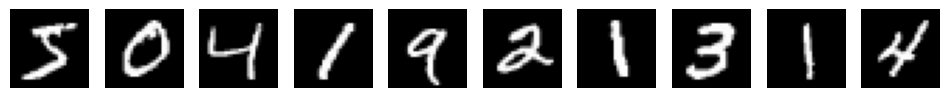

In [1]:
# (Optional) If you're on a fresh Colab: uncomment to ensure latest TF/Keras.
# %pip -q install -U tensorflow keras

import os, math, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt

import keras
from keras import layers, ops

# Data: MNIST 28x28 grayscale, scaled to [0,1]
# Keep labels so y_train / y_test are available as integer class IDs.
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Add channel dim: (N, 28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape, y_test[:10])


def show_images(imgs, n=10, title=None):
    """Show first n images from a batch (28x28x1)."""
    imgs = imgs[:n].squeeze()
    cols = n
    plt.figure(figsize=(1.2*cols, 1.5))
    for i in range(n):
        plt.subplot(1, cols, i+1)
        plt.imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
    if title:
        plt.suptitle(title, y=0.95)
    plt.show()

show_images(X_train)

# Part A — Autoencoder (AE)

**Idea:** Learn a compressed code `latent_space` that allows the decoder to reconstruct the input (minimize MSE).

In [2]:
from keras import layers, models, optimizers

latent_dim = 3

# ----- Encoder (Sequential) -----
encoder = models.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),                     # 14x14
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),                     # 7x7
        layers.Flatten(),
        layers.Dense(latent_dim, name="latent_space"),
    ],
    name="encoder",
)

# ----- Decoder (Sequential) -----
decoder = models.Sequential(
    [
        layers.Input(shape=(latent_dim,)),
        layers.Dense(7 * 7 * 64, activation="relu"),
        layers.Reshape((7, 7, 64)),
        layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same"),  # 14x14
        layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same"),  # 28x28
        layers.Conv2D(1, 3, activation="sigmoid", padding="same"),
    ],
    name="decoder",
)

# ----- Autoencoder = Encoder ∘ Decoder (Sequential) -----
autoencoder = models.Sequential([encoder, decoder], name="autoencoder")

encoder.summary()
decoder.summary()
autoencoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 3)              │         9,411 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,227 (110.26 KB)

 Trainable params: 28,227 (110.26 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 3)              │        28,227 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 28, 28, 1)      │        68,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,452 (376.77 KB)

 Trainable params: 96,452 (376.77 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss="mse")

history = autoencoder.fit(
    X_train, X_train,
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    verbose=1,
)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.0792 - val_loss: 0.0548
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.0470 - val_loss: 0.0430
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.0419 - val_loss: 0.0401
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 0.0398 - val_loss: 0.0385
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0386 - val_loss: 0.0374
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0376 - val_loss: 0.0365
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0370 - val_loss: 0.0359
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 0.0364 - val_loss: 0.0354
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - loss: 0.0360 - val_loss: 0.0350
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - loss: 0.0357 - val_loss: 0.0345
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - loss: 0.0354 - val_loss: 0.0344
Epoch 12/20
211/211 ━━━━━━━━━━

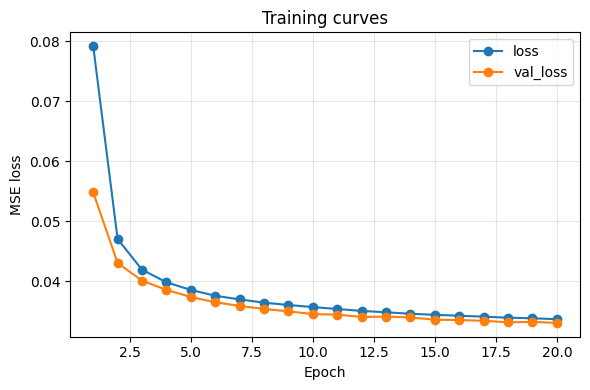

In [4]:
import matplotlib.pyplot as plt
h = history.history
epochs = range(1, len(h["loss"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, h["loss"], marker="o", label="loss")
if "val_loss" in h:
    plt.plot(epochs, h["val_loss"], marker="o", label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


-----------------------------------------------------------------------------------------------------------------------


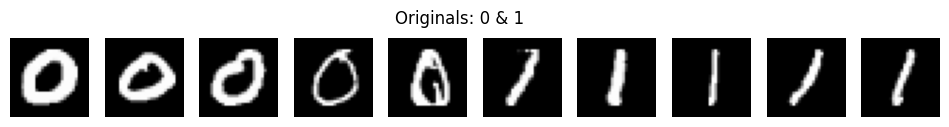

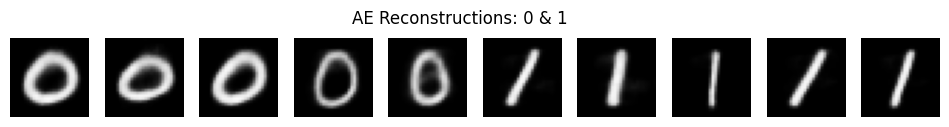

-----------------------------------------------------------------------------------------------------------------------


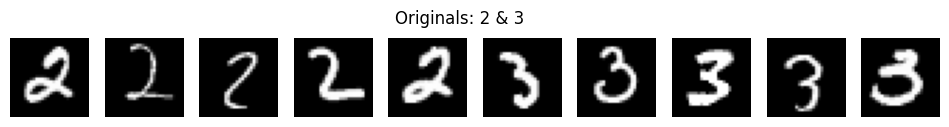

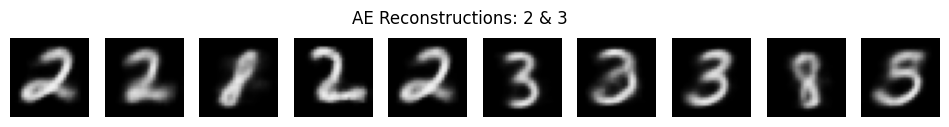

-----------------------------------------------------------------------------------------------------------------------


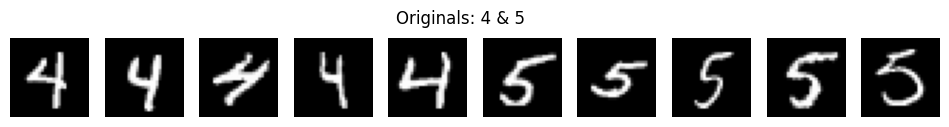

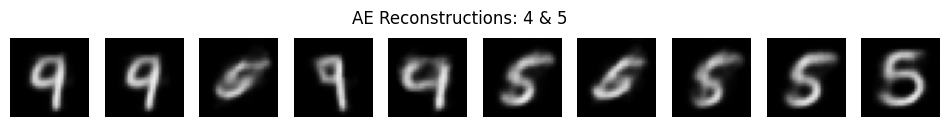

-----------------------------------------------------------------------------------------------------------------------


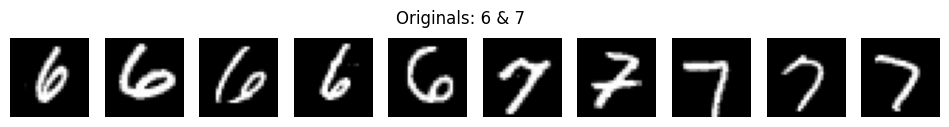

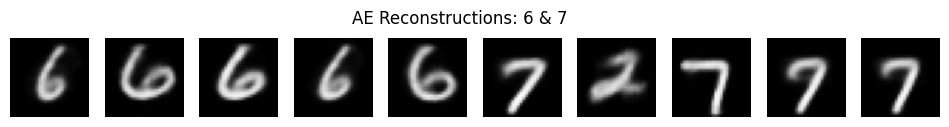

-----------------------------------------------------------------------------------------------------------------------


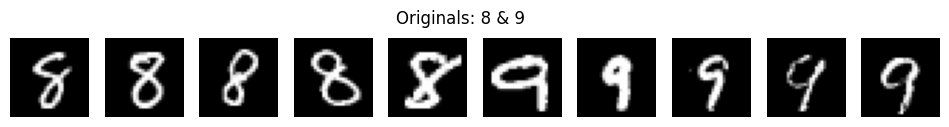

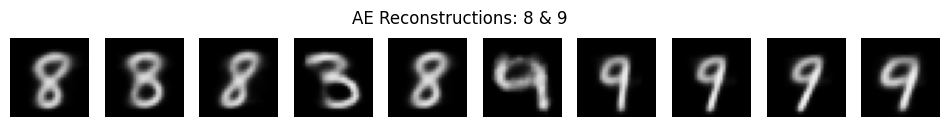

-----------------------------------------------------------------------------------------------------------------------


In [5]:
import numpy as np

# how many per class
k = 5

# RNG (set a seed for reproducibility; change/remove for fresh picks each run)
rng = np.random.default_rng()

pairs = [(0,1), (2,3), (4,5), (6,7), (8,9)]

print('-'*119)
for a, b in pairs:
    idx_a = np.where(y_test == a)[0]
    idx_b = np.where(y_test == b)[0]

    take_a = min(k, len(idx_a))
    take_b = min(k, len(idx_b))

    sel_a = rng.choice(idx_a, size=take_a, replace=False)
    sel_b = rng.choice(idx_b, size=take_b, replace=False)

    sel = np.concatenate([sel_a, sel_b])  # keep order: a's then b's
    batch = X_test[sel]
    recons = autoencoder.predict(batch, verbose=0)

    show_images(batch,  title=f"Originals: {a} & {b}")
    show_images(recons, title=f"AE Reconstructions: {a} & {b}")
    print('-'*119)

### What’s happening (intuition)

* With **latent_dim = 1**, the encoder maps each image to a **single scalar** (z \in \mathbb{R}). Yes, each digit image becomes a float.
* The decoder then learns a function (g:\mathbb{R}\to \text{image}) that turns that scalar back into a 28×28 image.
* The network tries to arrange digits **along a 1-D curve** (a “nonlinear PCA line”) so nearby (z) values reconstruct similar-looking digits.

  * Easy, “round” digits (like **0**) often get their own smooth region.
  * Ambiguous shapes (**4/9/7** etc.) **collide** on the same 1-D axis, so reconstructions look like “averaged” or “9-ish” digits.

### Visuals you can make now (1-D latent)

**A) See where each test image lands on the line**

In [6]:
# import numpy as np
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap

# # 1) Build a custom 10-color palette from tab10, but make "7" more distinct
# base = list(mpl.colormaps['tab10'].colors)  # 10 RGB tuples
# colors = base.copy()
# colors[7] = (0.80, 0.20, 0.80)  # vivid magenta for digit 7 (high contrast)
# cmap_digits = ListedColormap(colors, name='digits10_custom')

# # Get 1-D latents
# z_test = encoder.predict(X_test, verbose=0).squeeze()

# # 2) Scatter along the 1-D axis with custom colors
# plt.figure(figsize=(10, 3))
# jitter = (np.random.rand(len(z_test)) - 0.5) * 0.1
# point_colors = np.array([colors[d] for d in y_test])  # color per sample
# plt.scatter(z_test, jitter, c=point_colors, s=6)
# plt.yticks([])
# plt.xlabel("latent scalar z")
# plt.title("1-D latent positions")
# plt.show()

# # 3) Per-class histograms using the same palette
# plt.figure(figsize=(10, 6))
# bins = 60
# for d in range(10):
#     sel = (y_test == d)
#     hist, edges = np.histogram(z_test[sel], bins=bins)
#     centers = 0.5 * (edges[1:] + edges[:-1])
#     plt.plot(centers, hist, label=str(d), color=colors[d])
# plt.xlabel("z")
# plt.ylabel("count")
# plt.title("Distribution of latent space by class")
# plt.legend(ncol=5, fontsize=8)
# plt.show()


### 1-Dimensional Latent Space

The autocoder learns to associate each image with a scalar value. 

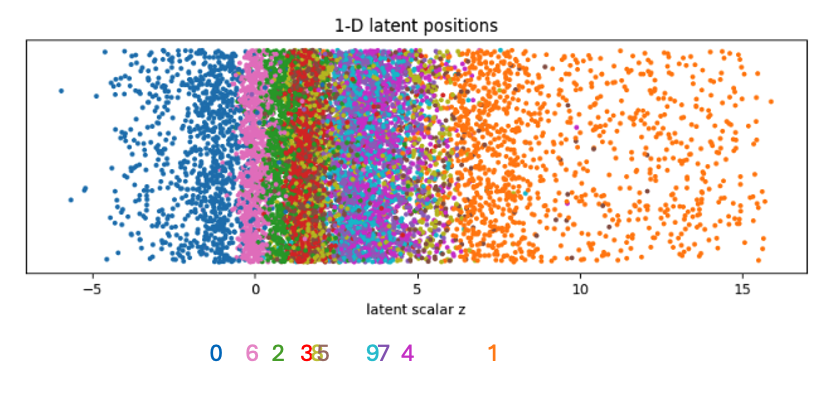

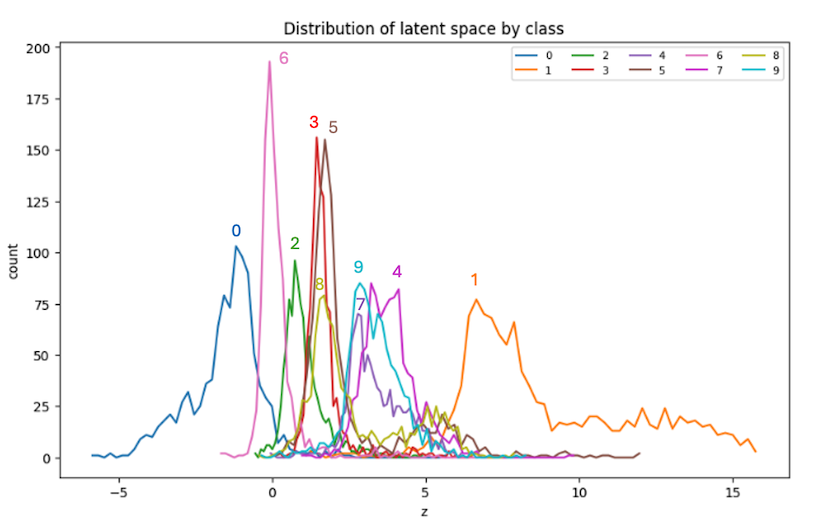

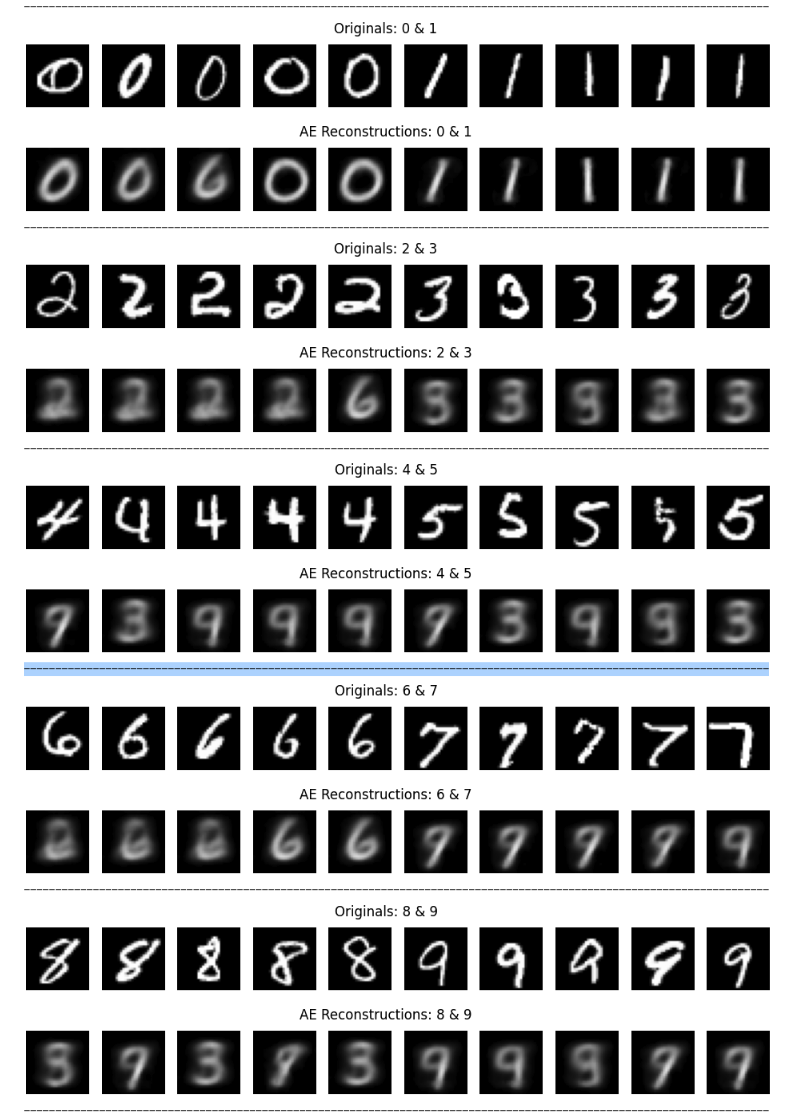

### Moving to 2-D latent space

Two dimensions let the model “spread out” classes on a surface instead of a line, reducing collisions and blur. 

**A) Scatter the 2-D embeddings**

In [7]:
# # Get 2-D latents
# z2_test = encoder.predict(X_test, verbose=0)  # shape (N, 2)

# plt.figure(figsize=(12, 12))
# plt.scatter(z2_test[:, 0], z2_test[:, 1], c=y_test, s=4, cmap="tab10", alpha=0.7)
# plt.xlabel("z1"); plt.ylabel("z2")
# plt.titlbe("2-D latent space colored by digit")
# plt.axis("equal")
# plt.show()

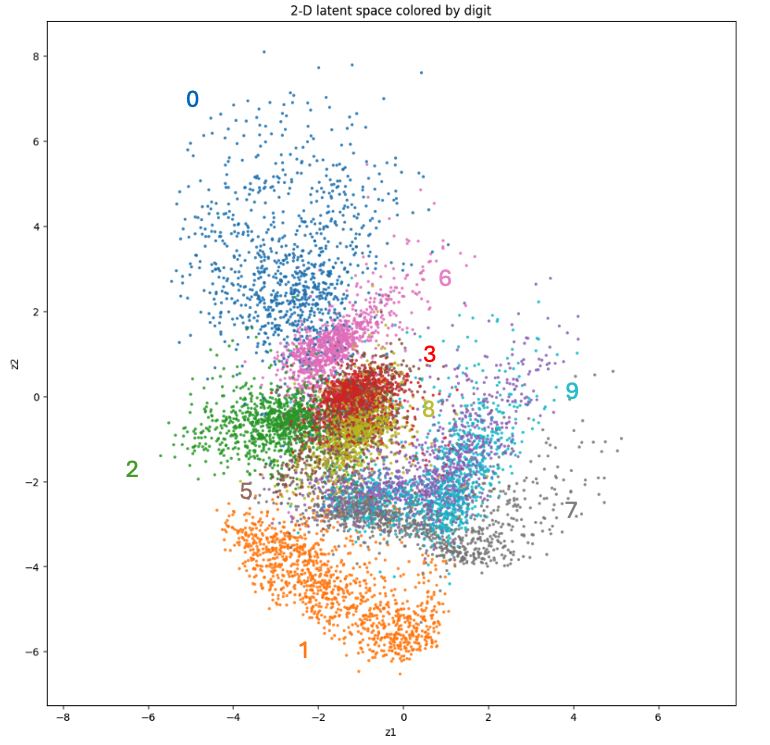

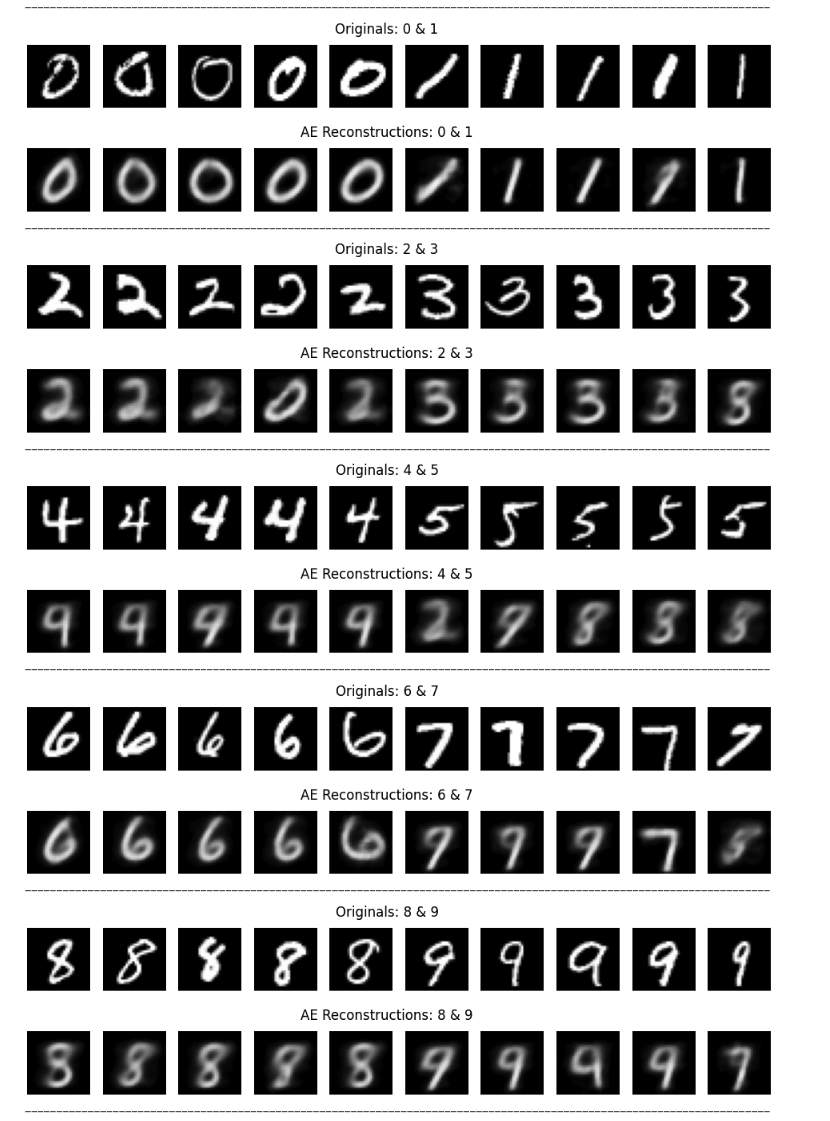

### MNIST digits in 3-Dimensional Latent Space

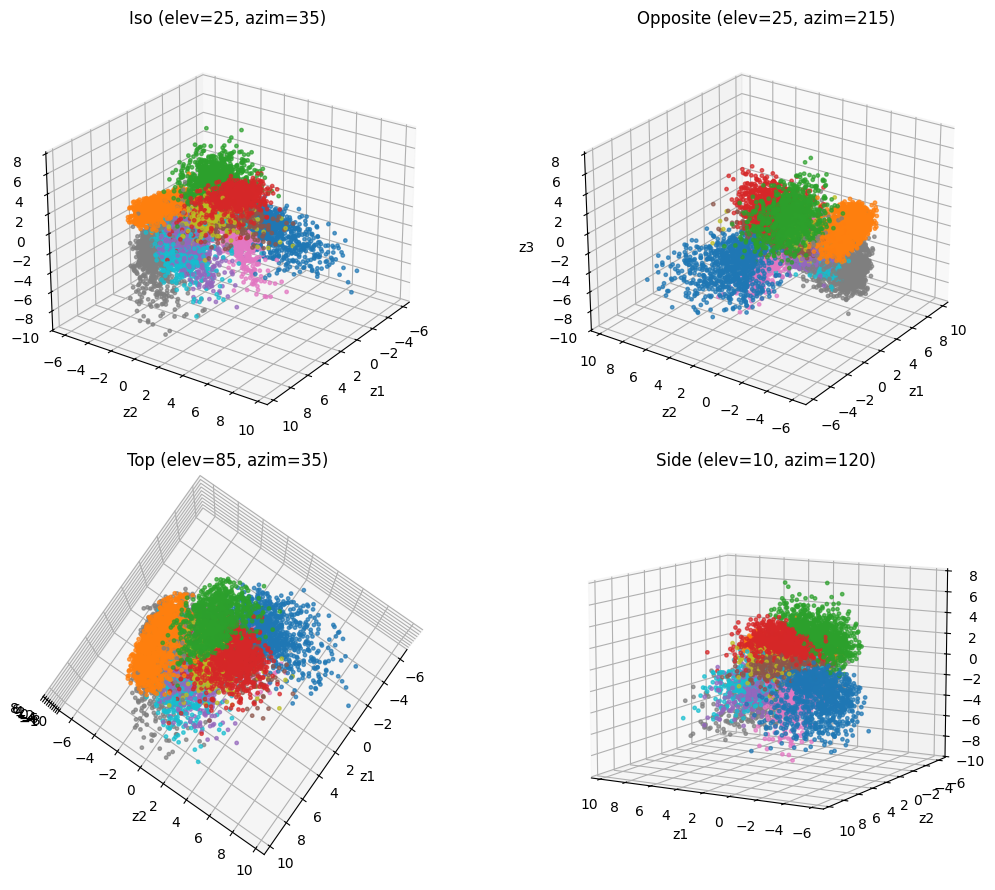

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D  # noqa

# data & colors
z3 = encoder.predict(X_test, verbose=0)
base = list(mpl.colormaps['tab10'].colors)
pt_colors = [base[d] for d in y_test]

views = [
    ("Iso (elev=25, azim=35)", 25, 35),
    ("Opposite (elev=25, azim=215)", 25, 215),
    # uncomment two more if you want 2×2
    ("Top (elev=85, azim=35)", 85, 35),
    ("Side (elev=10, azim=120)", 10, 120),
]

fig = plt.figure(figsize=(12, 9))
for i, (title, elev, azim) in enumerate(views):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.scatter(z3[:,0], z3[:,1], z3[:,2], c=pt_colors, s=6, alpha=0.7)
    ax.set_xlabel("z1"); ax.set_ylabel("z2"); ax.set_zlabel("z3")
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)

plt.tight_layout()
plt.show()



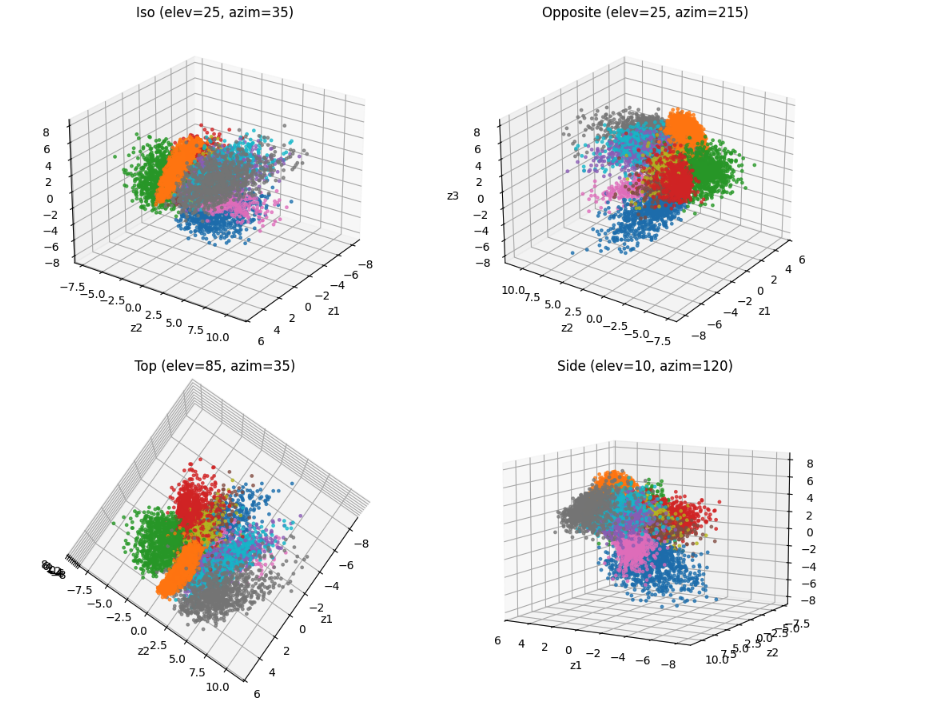

**B) Decode a grid (latent manifold visualization)**

### Uses for autoencoders

- Denoising
- Outlier Detection



# Part B — Variational Autoencoder (VAE)

**Main Idea:** Learn a *normal distribution* for each dimension in latent space, so we can **sample** new points and decode them to create new images. 


—defined by mean $\mu$ and log-variance $\log\sigma^2$ (so we can **sample** new points and decode them.

In [9]:
import keras
from keras import layers, ops
import tensorflow as tf

# ---- VAE class with robust reconstruction-loss reduction ----
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x, training=False):
        z_mean, z_log_var, z = self.encoder(x, training=training)
        return self.decoder(z, training=training)

    def _recon_kl_losses(self, x, recon, z_mean, z_log_var):
        # BCE per pixel -> reduce over all non-batch dims, then mean over batch
        bce_map = keras.losses.binary_crossentropy(x, recon)
        axes = tuple(range(1, len(bce_map.shape)))   # reduce H,W,(C) if present
        per_sample_recon = ops.mean(bce_map, axis=axes)
        recon_loss = ops.mean(per_sample_recon)

        # KL divergence (mean over batch)
        kl = -0.5 * ops.sum(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=1)
        kl_loss = ops.mean(kl)
        return recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            recon = self.decoder(z, training=True)
            recon_loss, kl_loss = self._recon_kl_losses(x, recon, z_mean, z_log_var)
            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        recon = self.decoder(z, training=False)
        recon_loss, kl_loss = self._recon_kl_losses(x, recon, z_mean, z_log_var)
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

# Reuse your existing encoder_vae / decoder_vae:
vae = VAE(encoder_vae, decoder_vae, name="vae")
vae.compile(optimizer=keras.optimizers.Adam(1e-3))  # add run_eagerly=True for debugging

# Train (uses your already-loaded X_train)
history = vae.fit(X_train, epochs=5, batch_size=256, validation_split=0.1, verbose=1)


NameError: name 'encoder_vae' is not defined

In [ ]:
# Reconstructions
recon = vae.predict(X_test[:10], verbose=0)
import matplotlib.pyplot as plt
def show_images(imgs, n=10, title=None):
    imgs = imgs[:n].squeeze()
    cols = n
    plt.figure(figsize=(1.2*cols, 1.5))
    for i in range(n):
        plt.subplot(1, cols, i+1); plt.imshow(imgs[i], cmap="gray", vmin=0, vmax=1); plt.axis("off")
    if title: plt.suptitle(title, y=0.95); plt.show()
show_images(X_test[:10], title="Originals")
show_images(recon,      title="VAE Reconstructions")

# Latent grid sampling (because latent_dim=2)
import numpy as np
def sample_grid(decoder, n=10, grid_lim=2.0):
    lin = np.linspace(-grid_lim, grid_lim, n)
    tiles = []
    for yi in lin:
        row = []
        for xi in lin:
            z = np.array([[xi, yi]], dtype="float32")
            img = decoder.predict(z, verbose=0)[0]
            row.append(img)
        tiles.append(np.hstack(row))
    canvas = np.vstack(tiles)
    plt.figure(figsize=(6,6))
    plt.imshow(canvas.squeeze(), cmap="gray", vmin=0, vmax=1); plt.axis("off"); plt.title("VAE latent grid"); plt.show()

sample_grid(decoder_vae, n=10, grid_lim=2.0)


**Talking point:** Smooth changes across the grid show a *continuous* latent space enabling interpolation & generation.

---

# Part C — Mini-GAN (DCGAN-style on MNIST)

**Idea:** Train a **Generator** $G(z)$ to produce digits that can fool a **Discriminator** $D(x)$. Adversarial game (minimax).

In [ ]:
import keras
from keras import layers

latent_dim = 64

# ----- Generator -----
def build_generator():
    z_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(7*7*128, use_bias=False)(z_in)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Reshape((7, 7, 128))(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)  # 14x14
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="tanh")(x)  # 28x28
    return keras.Model(z_in, x, name="generator")

# ----- Discriminator -----
def build_discriminator():
    X_in = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(64, 4, strides=2, padding="same")(X_in)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid")(x)  # using from_logits=False in your loss
    return keras.Model(X_in, out, name="discriminator")

gen = build_generator()
disc = build_discriminator()

gen.summary()
disc.summary()

# Optimizers & loss
g_opt = keras.optimizers.Adam(1e-4, beta_1=0.5)
d_opt = keras.optimizers.Adam(1e-4, beta_1=0.5)
bce = keras.losses.BinaryCrossentropy(from_logits=False)

# Preprocess real images to [-1,1] for tanh generator output
X_train_gan = (X_train * 2.0) - 1.0

@tf.function
def train_step(real_imgs, batch_size=128):
    # ----- Train Discriminator -----
    noise = tf.random.normal([batch_size, latent_dim])
    fake_imgs = gen(noise, training=True)

    with tf.GradientTape() as tape:
        real_pred = disc(real_imgs, training=True)
        fake_pred = disc(fake_imgs,  training=True)
        d_loss_real = bce(tf.ones_like(real_pred), real_pred)
        d_loss_fake = bce(tf.zeros_like(fake_pred), fake_pred)
        d_loss = d_loss_real + d_loss_fake
    grads = tape.gradient(d_loss, disc.trainable_variables)
    d_opt.apply_gradients(zip(grads, disc.trainable_variables))

    # ----- Train Generator (want discriminator to label fakes as real) -----
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake_imgs = gen(noise, training=True)
        fake_pred = disc(fake_imgs, training=True)
        g_loss = bce(tf.ones_like(fake_pred), fake_pred)
    grads = tape.gradient(g_loss, gen.trainable_variables)
    g_opt.apply_gradients(zip(grads, gen.trainable_variables))
    return d_loss, g_loss

def sample_generator(n=16):
    noise = tf.random.normal([n, latent_dim])
    imgs = gen.predict(noise, verbose=0)
    imgs = (imgs + 1.0) / 2.0  # back to [0,1]
    cols = int(math.sqrt(n))
    plt.figure(figsize=(1.5*cols, 1.5*cols))
    for i in range(n):
        plt.subplot(cols, cols, i+1)
        plt.imshow(imgs[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle("GAN Samples")
    plt.show()

# ----- Quick Training Loop -----
batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices(X_train_gan).shuffle(2048, seed=seed).batch(batch_size).prefetch(2)

steps = 2000  # small number for a fast demo
it = iter(dataset.repeat())
for step in range(1, steps+1):
    real_batch = next(it)
    d_loss, g_loss = train_step(real_batch, batch_size=real_batch.shape[0])
    if step % 200 == 0:
        print(f"Step {step}: D_loss={d_loss.numpy():.4f} | G_loss={g_loss.numpy():.4f}")
        sample_generator(n=16)

**Talking points while it trains:**

* Early samples look like noise; shapes emerge as $G$ learns to “fool” $D$.
* Contrast with VAE: GANs *sharper* outputs but training can be unstable.

---

## Instructor Notes (where this fits your lesson)

* **[Demo #1: AE]** right after you explain encoder ➜ bottleneck ➜ decoder.
* **[Demo #2: VAE]** immediately after introducing $\mu, \log\sigma^2$, KL term, and sampling.
* **[Demo #3: GAN]** after the “adversarial game” slide; run a short loop and show evolving samples.

If you’d like, I can bundle this into a single `.ipynb` with Markdown cells (titles, prompts, and brief equations) and add a final “Discussion” cell with 3–4 reflection questions.